# Extended Data Figure 8

Sam Gould, Kexin Dong

Analysis of sensor editing.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats
from sklearn.decomposition import PCA
from adjustText import adjust_text
from matplotlib_venn import venn2, venn3
from upsetplot import UpSet, from_indicators
import warnings
import os
warnings.filterwarnings('ignore')

# ── Global style (matching published figures) ─────────────────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

## 8a

Boxplot of target base editing rate, separated by the protospacer location (+4 to +8) of the target base, for ABE and CBE gRNAs with at least 10 sensor reads.

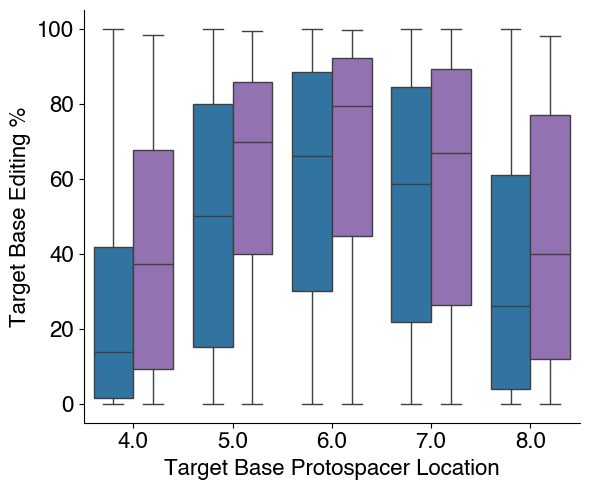

In [ ]:
master_targ = pd.read_csv('master_table_unfiltered.csv')

read_cutoff = 10
m = master_targ[(master_targ['sensor_reads']>=read_cutoff) & (master_targ['classification']=='targeting guide')]

fig, ax = plt.subplots(figsize=(6,5))

sns.boxplot(data = m, x='Protospacer_Location', y='target_base_edit_perc', hue='Editor', palette=['tab:blue', 'tab:purple'], legend=False)

ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=16,)
ax.set_ylabel('Target Base Editing %', fontsize=16)
ax.set_xlabel('Target Base Protospacer Location', fontsize=16)
fig.tight_layout()
#fig.savefig('figures/extended4a.pdf')

## 8b

CDF of target base editing rate for ABE (top) and CBE (bottom) gRNAs, for gRNAs with at least 10 sensor reads.

In [ ]:
MBES = pd.read_csv('MBESv2_CORRECTED.csv')

MBES_targ = MBES[MBES['classification']=='targeting guide']

ABE = MBES_targ[MBES_targ['Editor']=='ABE']
CBE = MBES_targ[MBES_targ['Editor']=='CBE']

ABE_guides = list(ABE['gRNA_id'])
CBE_guides = list(CBE['gRNA_id'])


k = os.listdir('ABE_editing/MLE')
names = []
dfs = []
for i in k:
    nombre = i.split('_')[0]

    aa = pd.read_csv(f'ABE_editing/MLE/{i}')
    aa = aa[aa['Guide_ID'].isin(ABE_guides)]
    names.append(nombre)
    dfs.append(aa)

ABE_mle_edit = dict(zip(names, dfs))

k = os.listdir('CBE_editing_UPDATED/MLE')

names = []
dfs = []
for i in k:
    nombre = i.split('_')[0]
    aa = pd.read_csv(f'CBE_editing_UPDATED/MLE/{i}')
    aa = aa[aa['Guide_ID'].isin(CBE_guides)]
    names.append(nombre)
    dfs.append(aa)

CBE_mle_edit = dict(zip(names, dfs))

## 8c

Pearson correlation matrix of target base editing rate among different ABE samples.

In [ ]:
#need to update and filter for sensor counts

read_cutoff = 10

d1 = dict(zip(list(ABE_mle_edit.keys()), ['INPUT', 'S', 'M', 'PLASMID', 'B', 'D5', 'D15']))


new_cols = []
reads = []
read_names = []
for i in CBE_mle_edit.keys():
    a = CBE_mle_edit[i]
    new_cols.append(a['target_base_edit_perc'])
    reads.append(a['Reads_aligned_all_amplicons'])
    read_names.append(f'reads_{i}')

names22 = [d1[i] for i in list(CBE_mle_edit.keys())]
CBE_editing = pd.DataFrame(dict(zip(names22, new_cols)))

CBE_reads = pd.DataFrame(dict(zip(read_names, reads)))
CBE_editing_combined = pd.concat([CBE_editing, CBE_reads], axis=1)
CBE_editing_filtered = CBE_editing_combined[(CBE_editing_combined['reads_input']>=read_cutoff) & (CBE_editing_combined['reads_spleen']>=read_cutoff) & (CBE_editing_combined['reads_meninges']>=read_cutoff) & (CBE_editing_combined['reads_plasmid']>=read_cutoff) & (CBE_editing_combined['reads_bonemarrow']>=read_cutoff) & (CBE_editing_combined['reads_d5']>=read_cutoff) &(CBE_editing_combined['reads_d15']>=read_cutoff)]



new_cols = []
reads = []
read_names = []
for i in ABE_mle_edit.keys():
    a = ABE_mle_edit[i]
    new_cols.append(a['target_base_edit_perc'])
    reads.append(a['Reads_aligned_all_amplicons'])
    read_names.append(f'reads_{i}')


names22 = [d1[i] for i in list(ABE_mle_edit.keys())]
ABE_editing = pd.DataFrame(dict(zip(names22, new_cols)))
ABE_reads = pd.DataFrame(dict(zip(read_names, reads)))

ABE_editing_combined = pd.concat([ABE_editing, ABE_reads], axis=1)

ABE_editing_filtered = ABE_editing_combined[(ABE_editing_combined['reads_input']>=read_cutoff) & (ABE_editing_combined['reads_spleen']>=read_cutoff) & (ABE_editing_combined['reads_meninges']>=read_cutoff) & (ABE_editing_combined['reads_plasmid']>=read_cutoff) & (ABE_editing_combined['reads_bonemarrow']>=read_cutoff) & (ABE_editing_combined['reads_d5']>=read_cutoff) &(ABE_editing_combined['reads_d15']>=read_cutoff)]
ABE_editing_filtered

,INPUT,S,M,PLASMID,B,D5,D15,reads_input,reads_spleen,reads_meninges,reads_plasmid,reads_bonemarrow,reads_d5,reads_d15
0,0.000000,4.991948,36.962025,0.0,4.191617,1.929530,13.364055,699,621,1185,121,1169,1192,868
3,0.000000,56.792688,8.047465,0.0,53.646738,22.960152,40.912969,858,4814,4635,185,8062,2108,2344
57,1.283697,39.771547,71.227197,0.0,76.371308,65.404930,65.272727,779,1926,2412,243,4977,2272,2200
91,0.410537,67.907634,94.911783,0.0,70.086207,79.592406,86.170468,2923,4244,6348,483,4640,3582,4165
102,3.708609,96.437055,90.697674,0.0,87.095658,91.070336,98.797737,2265,1263,5074,330,5781,3270,2828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14275,0.000000,83.435583,99.699609,0.0,94.270833,94.256259,93.638677,518,489,3329,160,960,679,786
14281,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,161,217,198,75,257,103,93
14324,1.269036,10.655738,0.439883,0.0,7.033278,4.115523,6.906615,1576,1342,1364,180,4237,2770,2056
14335,0.000000,27.673167,13.601236,0.0,14.955040,38.813283,37.428896,1140,2974,647,158,4226,1837,1758


[Text(1, 0.5, 'M'),
 Text(1, 1.5, 'S'),
 Text(1, 2.5, 'B'),
 Text(1, 3.5, 'D5'),
 Text(1, 4.5, 'D15'),
 Text(1, 5.5, 'INPUT'),
 Text(1, 6.5, 'PLASMID')]

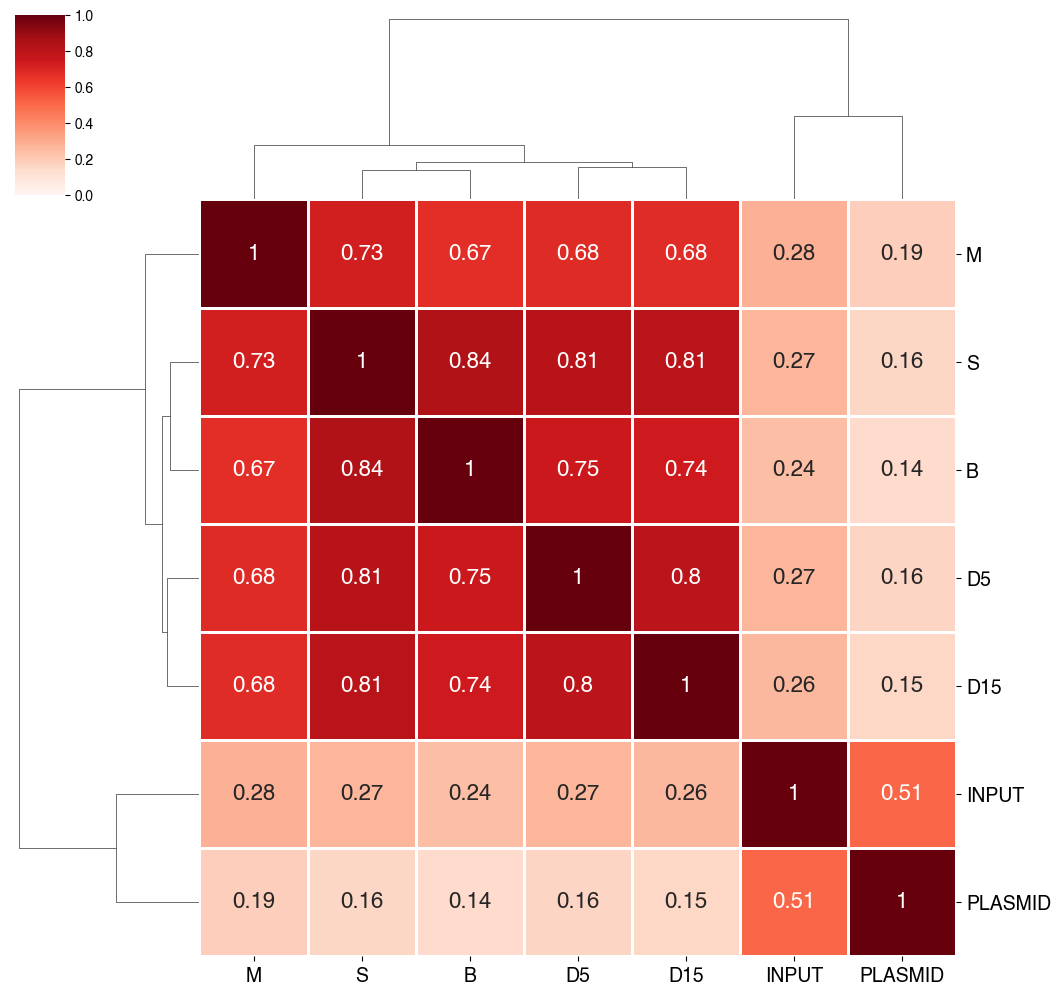

In [ ]:
g = sns.clustermap(CBE_editing_filtered[names22].corr(method='pearson'), cmap='Reds', vmin=0, annot=True, linewidth=1, annot_kws={"size": 16})

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize = 14)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize = 14, rotation=0)
#g.savefig('figures/CBE_editing_heatmap.pdf')

## 8d

Pearson correlation matrix of target base editing rate among different CBE samples.

[Text(1, 0.5, 'M'),
 Text(1, 1.5, 'D5'),
 Text(1, 2.5, 'D15'),
 Text(1, 3.5, 'S'),
 Text(1, 4.5, 'B'),
 Text(1, 5.5, 'INPUT'),
 Text(1, 6.5, 'PLASMID')]

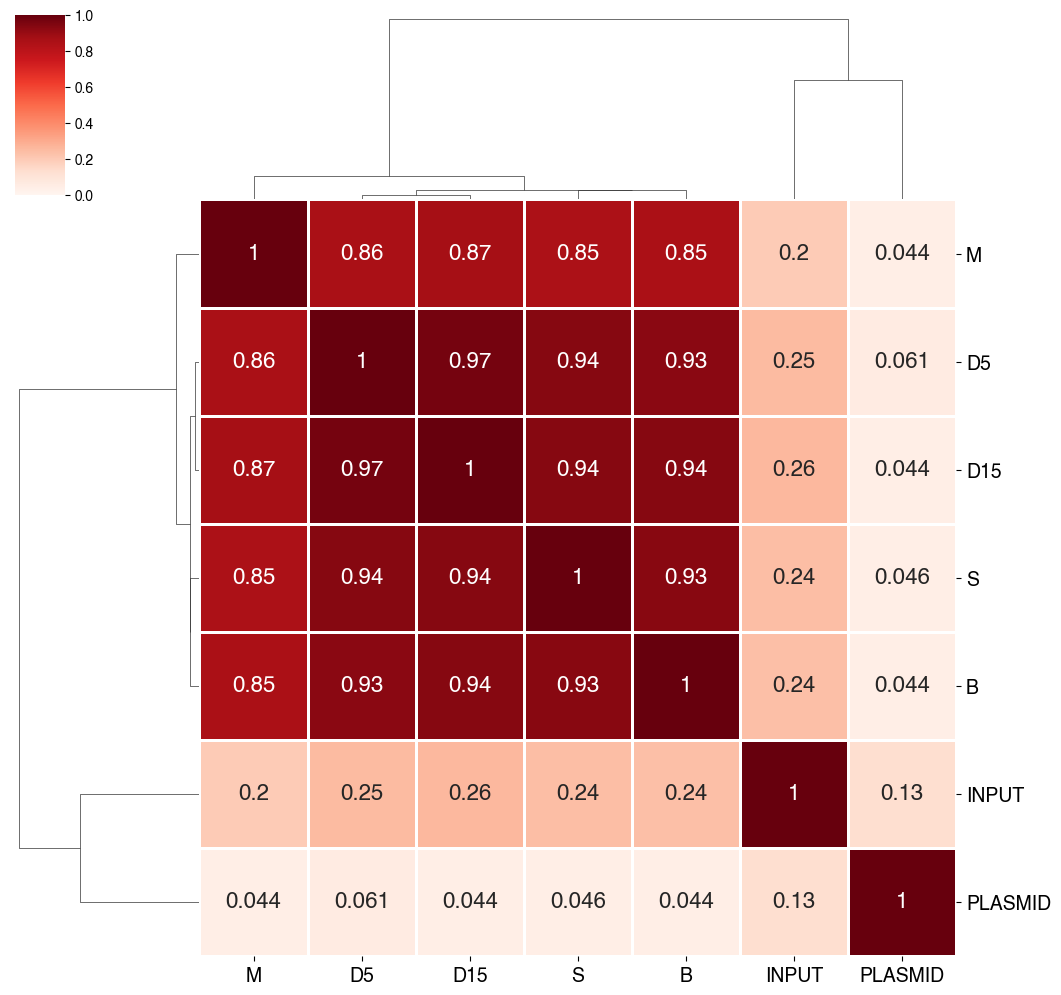

In [ ]:
g = sns.clustermap(ABE_editing_filtered[names22].corr(method='pearson'), cmap='Reds', vmin=0, annot=True, linewidth=1, annot_kws={"size": 16})

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize = 14)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize = 14, rotation=0)
#g.savefig('figures/ABE_editing_heatmap.pdf')